<a href="https://colab.research.google.com/github/sujata464/Ecommerce/blob/main/INTERNSHIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All libraries imported successfully!

Dataset loaded successfully!

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Last 5 rows:
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

Dataset Shape:
(200, 5)

Column Names:


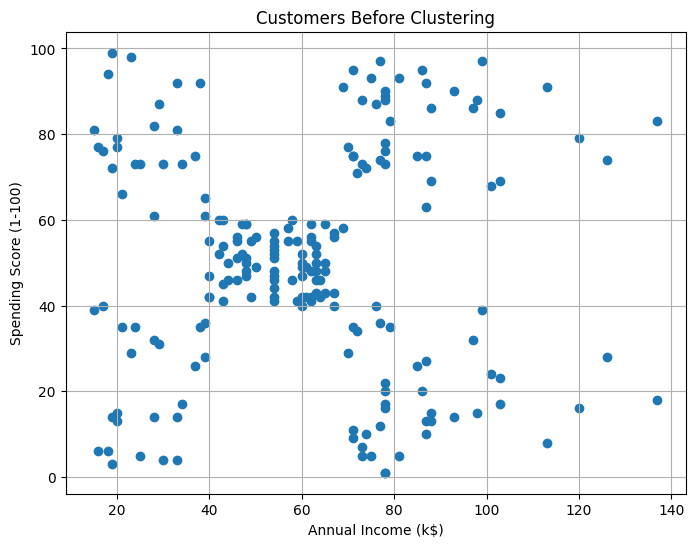


Data standardized successfully!


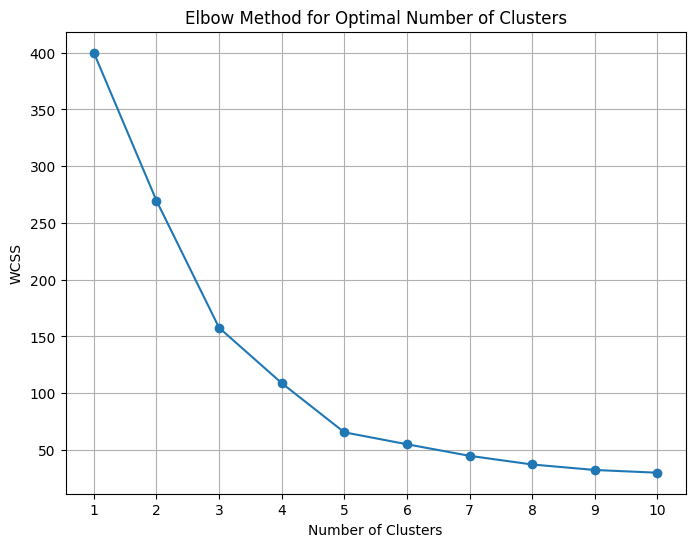


K-Means clustering completed successfully!

Clustered Dataset:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0            1    Male   19                  15                      39   
1            2    Male   21                  15                      81   
2            3  Female   20                  16                       6   
3            4  Female   23                  16                      77   
4            5  Female   31                  17                      40   
5            6  Female   22                  17                      76   
6            7  Female   35                  18                       6   
7            8  Female   23                  18                      94   
8            9    Male   64                  19                       3   
9           10  Female   30                  19                      72   
10          11    Male   67                  19                      14   
11          12  Female   35         

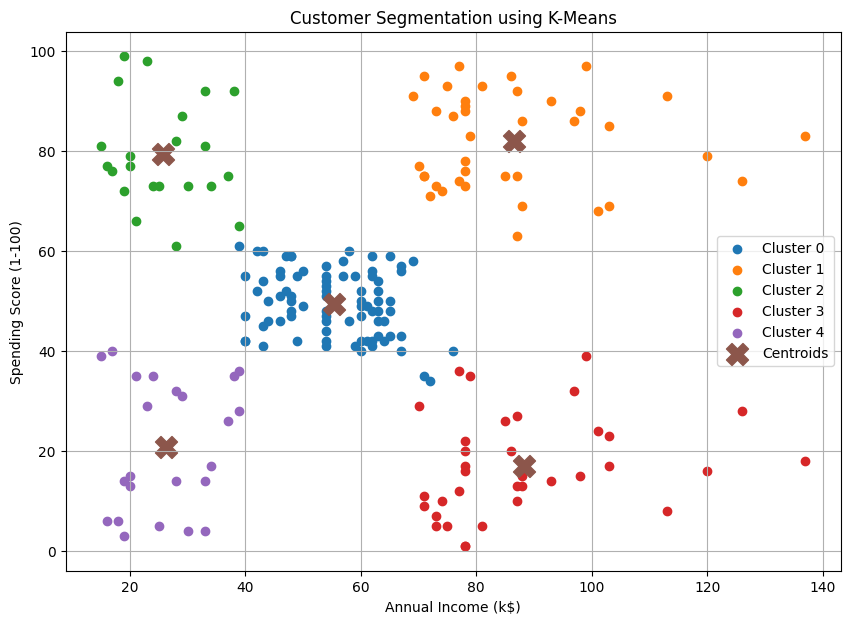


Silhouette Score:
0.5547

Cluster Summary:
           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        42.72               55.30                   49.52
1        32.69               86.54                   82.13
2        25.27               25.73                   79.36
3        41.11               88.20                   17.11
4        45.22               26.30                   20.91

Customer Count:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Customer Segments:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0            1    Male   19                  15                      39   
1            2    Male   21                  15                      81   
2            3  Female   20                  16                       6   
3            4  Female   23                  16                      77   
4            5  Female   31                  17          

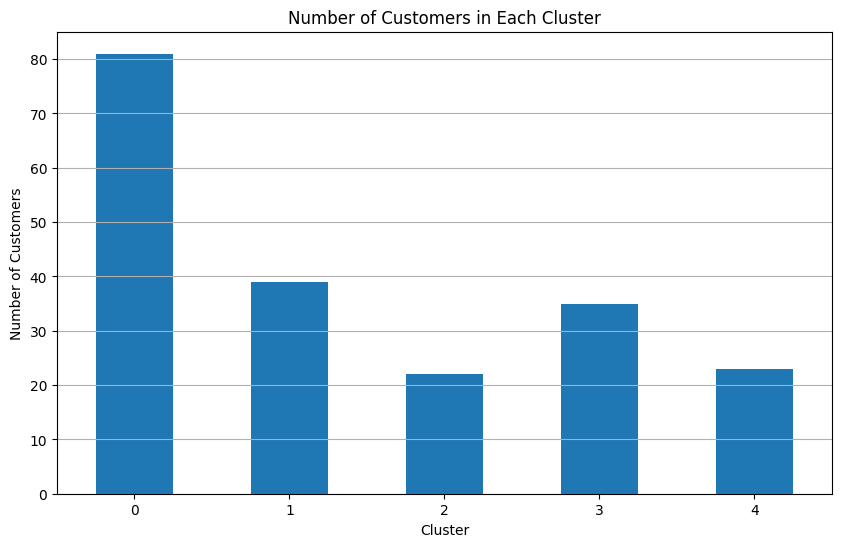


Final dataset saved successfully as: Customer_Segmentation_Result.csv
Cluster summary saved successfully as: Customer_Segment_Summary.csv

       PROJECT COMPLETED SUCCESSFULLY

Total Customers: 200
Number of Clusters: 5
Silhouette Score: 0.5547

Files generated:
1. Customer_Segmentation_Result.csv
2. Customer_Segment_Summary.csv

Customer Segmentation Completed!


In [2]:
# ============================================================
# PRODIGY INFOTECH - TASK 02
# Customer Segmentation using K-Means Clustering
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("All libraries imported successfully!")


# ------------------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------------------

url = "https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv"

df = pd.read_csv(url)

print("\nDataset loaded successfully!")


# ------------------------------------------------------------
# 3. DISPLAY DATASET
# ------------------------------------------------------------

print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())


# ------------------------------------------------------------
# 4. DATASET INFORMATION
# ------------------------------------------------------------

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()


# ------------------------------------------------------------
# 5. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 6. CHECK DUPLICATE VALUES
# ------------------------------------------------------------

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


# Remove duplicate rows if any
df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)


# ------------------------------------------------------------
# 7. STATISTICAL SUMMARY
# ------------------------------------------------------------

print("\nStatistical Summary:")
print(df.describe())


# ------------------------------------------------------------
# 8. SELECT FEATURES FOR CLUSTERING
# ------------------------------------------------------------

# We use Annual Income and Spending Score
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print("\nFeatures selected for clustering:")
print(X.head())


# ------------------------------------------------------------
# 9. VISUALIZE ORIGINAL DATA
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.title("Customers Before Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 10. STANDARDIZE THE DATA
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nData standardized successfully!")


# ------------------------------------------------------------
# 11. ELBOW METHOD
# ------------------------------------------------------------

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)


# Plot Elbow Curve

plt.figure(figsize=(8, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.xticks(range(1, 11))
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 12. APPLY K-MEANS WITH 5 CLUSTERS
# ------------------------------------------------------------

kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

# Train the model
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = cluster_labels

print("\nK-Means clustering completed successfully!")


# ------------------------------------------------------------
# 13. DISPLAY CLUSTERED DATA
# ------------------------------------------------------------

print("\nClustered Dataset:")
print(
    df[
        [
            'CustomerID',
            'Gender',
            'Age',
            'Annual Income (k$)',
            'Spending Score (1-100)',
            'Cluster'
        ]
    ].head(20)
)


# ------------------------------------------------------------
# 14. COUNT CUSTOMERS IN EACH CLUSTER
# ------------------------------------------------------------

print("\nNumber of customers in each cluster:")

print(
    df['Cluster']
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 15. VISUALIZE K-MEANS CLUSTERS
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

for cluster in range(5):

    cluster_data = df[df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        label=f'Cluster {cluster}'
    )


# Convert cluster centers back to original scale
centers_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)


# Plot cluster centers

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker='X',
    s=250,
    label='Centroids'
)


plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 16. SILHOUETTE SCORE
# ------------------------------------------------------------

silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print("\nSilhouette Score:")
print(round(silhouette, 4))


# ------------------------------------------------------------
# 17. CLUSTER ANALYSIS
# ------------------------------------------------------------

cluster_summary = df.groupby('Cluster').agg({

    'Age': 'mean',

    'Annual Income (k$)': 'mean',

    'Spending Score (1-100)': 'mean'

}).round(2)


print("\nCluster Summary:")
print(cluster_summary)


# ------------------------------------------------------------
# 18. CUSTOMER COUNT BY CLUSTER
# ------------------------------------------------------------

customer_count = df['Cluster'].value_counts().sort_index()

print("\nCustomer Count:")
print(customer_count)


# ------------------------------------------------------------
# 19. ADD CUSTOMER SEGMENT NAMES
# ------------------------------------------------------------

# The cluster numbers can change depending on the model.
# We assign names according to average income and spending.

segment_names = {}

for cluster in cluster_summary.index:

    income = cluster_summary.loc[
        cluster,
        'Annual Income (k$)'
    ]

    spending = cluster_summary.loc[
        cluster,
        'Spending Score (1-100)'
    ]

    if income >= cluster_summary['Annual Income (k$)'].median():

        if spending >= cluster_summary['Spending Score (1-100)'].median():
            name = "High Income - High Spending"
        else:
            name = "High Income - Low Spending"

    else:

        if spending >= cluster_summary['Spending Score (1-100)'].median():
            name = "Low Income - High Spending"
        else:
            name = "Low Income - Low Spending"

    segment_names[cluster] = name


df['Customer Segment'] = df['Cluster'].map(segment_names)


# ------------------------------------------------------------
# 20. DISPLAY CUSTOMER SEGMENTS
# ------------------------------------------------------------

print("\nCustomer Segments:")

print(
    df[
        [
            'CustomerID',
            'Gender',
            'Age',
            'Annual Income (k$)',
            'Spending Score (1-100)',
            'Cluster',
            'Customer Segment'
        ]
    ].head(20)
)


# ------------------------------------------------------------
# 21. SEGMENT SUMMARY
# ------------------------------------------------------------

segment_summary = df.groupby(
    'Customer Segment'
).agg({

    'CustomerID': 'count',

    'Age': 'mean',

    'Annual Income (k$)': 'mean',

    'Spending Score (1-100)': 'mean'

}).round(2)


segment_summary = segment_summary.rename(
    columns={
        'CustomerID': 'Number of Customers'
    }
)


print("\nFinal Segment Summary:")
print(segment_summary)


# ------------------------------------------------------------
# 22. BAR CHART - NUMBER OF CUSTOMERS
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

customer_count.plot(
    kind='bar'
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()


# ------------------------------------------------------------
# 23. SAVE CLUSTERED DATASET
# ------------------------------------------------------------

output_file = "Customer_Segmentation_Result.csv"

df.to_csv(
    output_file,
    index=False
)

print(
    f"\nFinal dataset saved successfully as: {output_file}"
)


# ------------------------------------------------------------
# 24. SAVE CLUSTER SUMMARY
# ------------------------------------------------------------

summary_file = "Customer_Segment_Summary.csv"

segment_summary.to_csv(
    summary_file
)

print(
    f"Cluster summary saved successfully as: {summary_file}"
)


# ------------------------------------------------------------
# 25. FINAL RESULT
# ------------------------------------------------------------

print("\n==========================================")
print("       PROJECT COMPLETED SUCCESSFULLY")
print("==========================================")

print("\nTotal Customers:", len(df))

print("Number of Clusters:", 5)

print(
    "Silhouette Score:",
    round(silhouette, 4)
)

print("\nFiles generated:")

print("1. Customer_Segmentation_Result.csv")
print("2. Customer_Segment_Summary.csv")

print("\nCustomer Segmentation Completed!")